In [13]:
import wrds
import pandas as pd

In [ ]:
username = "YOUR_WRDS_USERNAME"
db = wrds.Connection(wrds_username=username)

In [ ]:
pip install matplotlib scipy pandas numpy statsmodels scikit-learn seaborn

In [16]:
import pandas as pd                
import matplotlib.pyplot as plt    
from scipy import stats            
import numpy as np                 

In [17]:
import statsmodels.api as sm

In [18]:
all_data = []
for year in [2020,2021,2022,2023,2024]:
    print(f"pulling the data for {year} ...")
    
    temp = db.raw_sql(f"""
    SELECT stkcd, accper, typrep, 
           a001000000, b001100000, c001000000, a002000000
    FROM csmar.wrds_csmar_financial_master
    WHERE accper BETWEEN '{year}-01-01' AND '{year}-12-31'
      AND typrep = 'A'
      AND a001000000 > 0
      AND b001100000 > 0
    """)
    
    all_data.append(temp)

china_financial_data = pd.concat(all_data, ignore_index=True)  

pulling the data for 2020 ...
pulling the data for 2021 ...
pulling the data for 2022 ...
pulling the data for 2023 ...
pulling the data for 2024 ...


In [19]:
#Remove the impact of quarterly reports and retain only the annual reports.
china_financial_data['accper'] = china_financial_data['accper'].astype(str)
df_step1 = china_financial_data[china_financial_data['accper'].str.endswith('-12-31')].copy()
df_step1 = df_step1.drop_duplicates(subset=['stkcd', 'accper'], keep='first')

print("Processed data", len(df_step1))
print("The first five values of the accper：")
print(df_step1['accper'].head())

Processed data 25796
The first five values of the accper：
4     2020-12-31
9     2020-12-31
14    2020-12-31
19    2020-12-31
24    2020-12-31
Name: accper, dtype: str


In [20]:
#Re-import the modified date data back into the table
cols_keep = ['stkcd', 'accper', 'a001000000', 'b001100000', 'c001000000', 'a002000000']
df_step2 = df_step1[cols_keep].copy()

print("data size", df_step2.shape)
print("\ntype of each column：")
print(df_step2.dtypes)
print("\nfirst five rows：")
print(df_step2.head())

data size (25796, 6)

type of each column：
stkcd          string
accper            str
a001000000    Float64
b001100000    Float64
c001000000    Float64
a002000000    Float64
dtype: object

first five rows：
     stkcd      accper            a001000000           b001100000  \
4   000001  2020-12-31       4468514000000.0       143242000000.0   
9   000002  2020-12-31  1869177094005.550049  419111677714.119995   
14  000004  2020-12-31         1563562870.86         280531008.22   
19  000005  2020-12-31         2452795303.51         398921057.66   
24  000006  2020-12-31    15434760023.280001        2934733294.89   

            c001000000            a002000000  
4       -16161000000.0       4104383000000.0  
9   53188022243.809998  1519332620662.330078  
14          3973925.97          106734607.45  
19        116373610.28          1126875461.8  
24        -167505495.3         7596761855.69  


In [21]:
#Remove the null values from the data to ensure the normal operation of the calculation.
cols_raw = ['a001000000', 'b001100000', 'c001000000', 'a002000000']
df_step3 = df_step2.dropna(subset=cols_raw).copy()

print("processed data：", len(df_step3))
print("\nnumber of missing values：")
print(df_step3[cols_raw].isnull().sum())

processed data： 25795

number of missing values：
a001000000    0
b001100000    0
c001000000    0
a002000000    0
dtype: int64


In [22]:
#Keep the positive numbers to avoid any problems when calculating ROA and the asset-liability ratio.
df_step4 = df_step3[
    (df_step3['a001000000'] > 0) &   
    (df_step3['b001100000'] > 0)     
].copy()

print("processed data：", len(df_step4))

processed data： 25795


In [23]:
# calculate ROA & Leverage ratio
df_step5 = df_step4.copy()

#ROA
df_step5['roa'] = df_step5['c001000000'] / df_step5['a001000000']

#Leverage
df_step5['lev'] = df_step5['a002000000'] / df_step5['a001000000']

#Take the logarithm to ensure the regression effect
df_step5['log_at'] = np.log(df_step5['a001000000'])
df_step5['log_revt'] = np.log(df_step5['b001100000'])

print("ok!")
print("row sizw：", len(df_step5))
print("\nfirst 5 rows of the new datas：")
print(df_step5[['roa', 'lev', 'log_at', 'log_revt']].head())
print("\nnew type：")
print(df_step5[['roa', 'lev', 'log_at', 'log_revt']].dtypes)

ok!
row sizw： 25795

first 5 rows of the new datas：
         roa       lev     log_at   log_revt
4  -0.003617  0.918512  29.128077  25.687801
9   0.028455  0.812835  28.256519  26.761403
14  0.002542  0.068264  21.170233  19.452195
19  0.047445  0.459425  21.620494  19.804274
24 -0.010852  0.492185  23.459888  21.799882

new type：
roa         Float64
lev         Float64
log_at      Float64
log_revt    Float64
dtype: object


In [24]:
#Eliminate outliers
cols_reg = ['log_revt', 'log_at', 'roa', 'lev']

#Remove null values
df_step6 = df_step5.dropna(subset=cols_reg).copy()

#Eliminate positive and negative infinity
df_step6 = df_step6[np.isfinite(df_step6[cols_reg]).all(axis=1)]

print("Final cleaning completed!")
print("row size：", len(df_step6))
print("\nThe number of missing values for each variable：")
print(df_step6[cols_reg].isnull().sum())

Final cleaning completed!
row size： 25795

The number of missing values for each variable：
log_revt    0
log_at      0
roa         0
lev         0
dtype: int64


In [25]:
#LinearRegression
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_step6[['log_at', 'roa', 'lev']].values
y = df_step6['log_revt'].values

model = LinearRegression()
model.fit(X, y)

print("Regression coefficient：", model.coef_)
print("intercept：", model.intercept_)
print("R²：", model.score(X, y))

Regression coefficient： [ 8.94684513e-01  2.18406653e+00 -2.05885352e-03]
intercept： 1.420885932180898
R²： 0.7648945928198064


In [26]:
# Force conversion to a pure numpy float64 array to resolve the incompatibility issue
X = np.asarray(df_step6[['log_at', 'roa', 'lev']], dtype=np.float64)
y = np.asarray(df_step6['log_revt'], dtype=np.float64)
#Output the complete regression results
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                 1.184e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:17:41   Log-Likelihood:                -30235.
No. Observations:               25795   AIC:                         6.048e+04
Df Residuals:                   25791   BIC:                         6.051e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4209      0.279      5.089      0.0

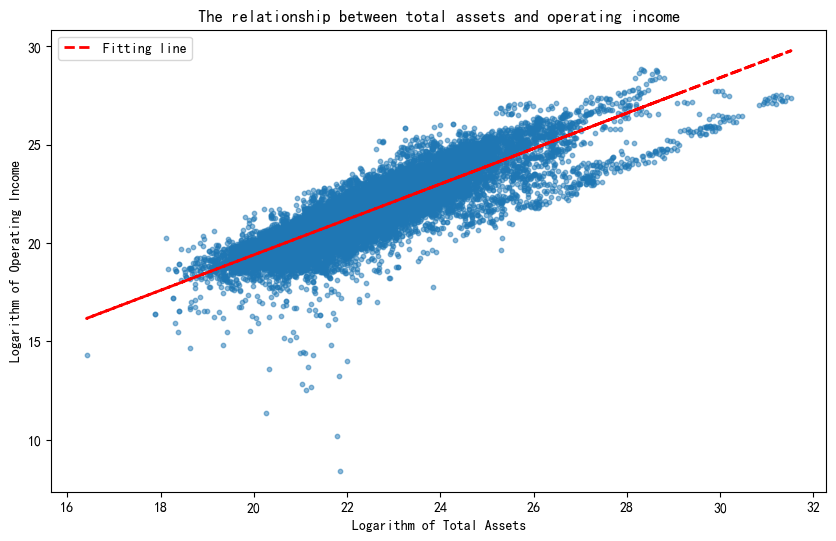

In [27]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,6))
plt.scatter(df_step6['log_at'], df_step6['log_revt'], s=10, alpha=0.5)
plt.xlabel('Logarithm of Total Assets')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between total assets and operating income')

z = np.polyfit(df_step6['log_at'], df_step6['log_revt'], 1)
p = np.poly1d(z)
plt.plot(df_step6['log_at'], p(df_step6['log_at']), 'r--', lw=2, label='Fitting line')
plt.legend()
plt.show()

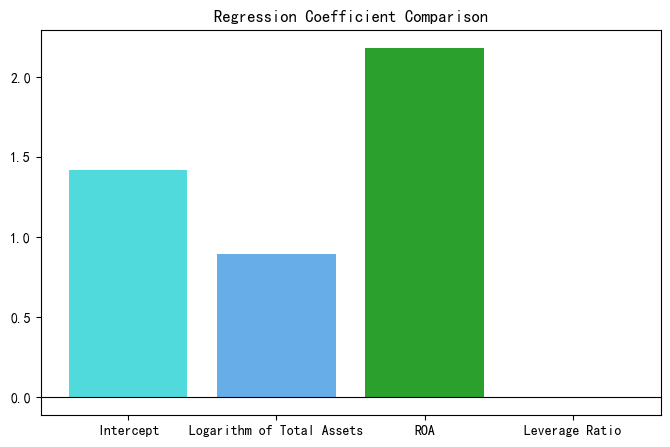

In [32]:
coefs = model.params 
names = ['Intercept', 'Logarithm of Total Assets', 'ROA', 'Leverage Ratio']

plt.figure(figsize=(8,5))
plt.bar(names, coefs, color=["#50dadc", "#67aee8", '#2ca02c'])
plt.title('Regression Coefficient Comparison')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

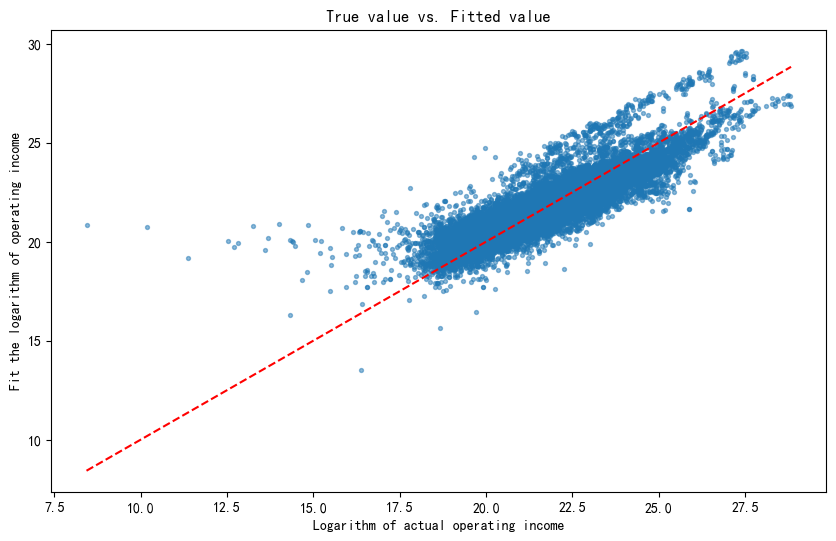

In [33]:
y_fit = model.predict(X)

plt.figure(figsize=(10,6))
plt.scatter(y, y_fit, s=8, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Logarithm of actual operating income')
plt.ylabel('Fit the logarithm of operating income')
plt.title('True value vs. Fitted value')
plt.show()

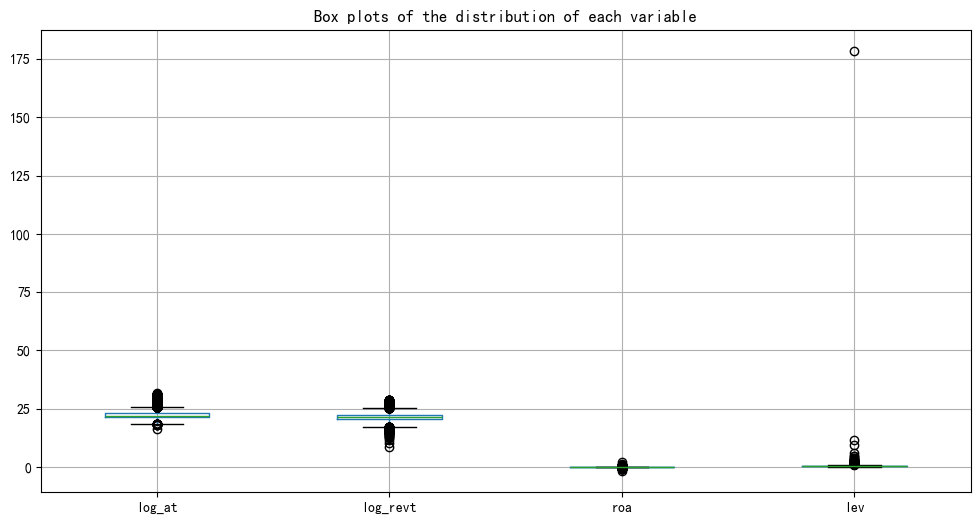

In [34]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df_step6[['log_at', 'log_revt', 'roa', 'lev']].boxplot(figsize=(12,6))
plt.title('Box plots of the distribution of each variable')
plt.show()

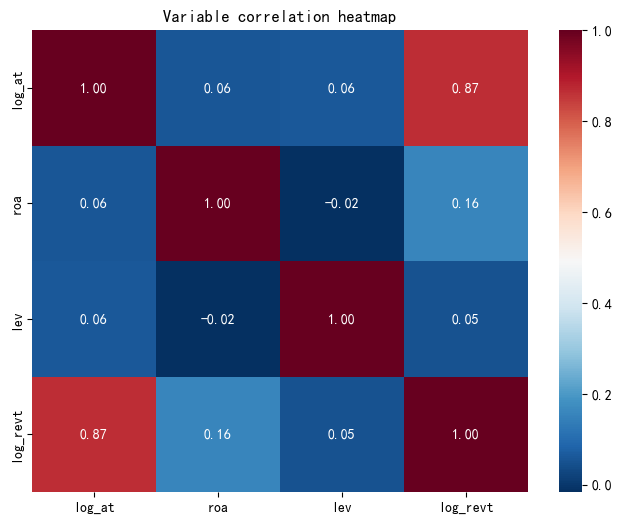

In [35]:
import seaborn as sns
corr = df_step6[['log_at', 'roa', 'lev', 'log_revt']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Variable correlation heatmap')
plt.show()

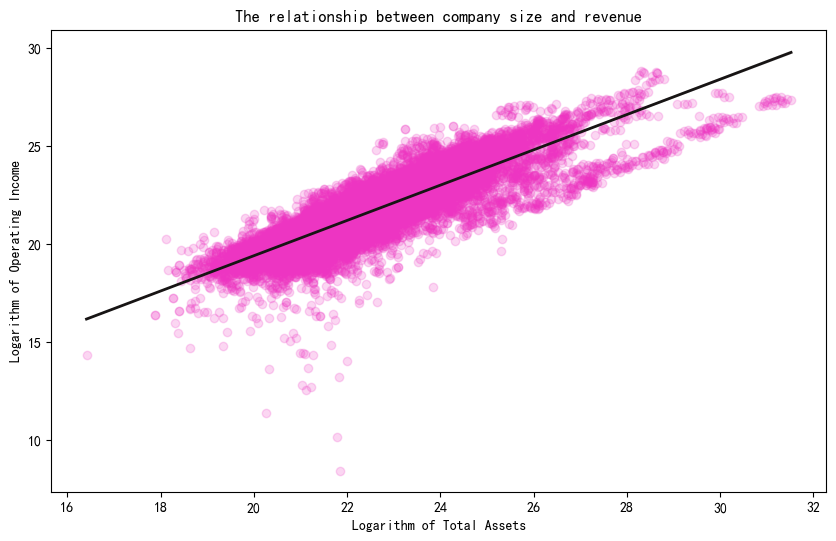

In [36]:
plt.figure(figsize=(10,6))
sns.regplot(x=df_step6['log_at'], y=df_step6['log_revt'], scatter_kws={'color':"#ED35C2", 'alpha':0.2}, line_kws={'color':"#171414", 'lw':2}) 
plt.xlabel('Logarithm of Total Assets')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between company size and revenue')
plt.show()

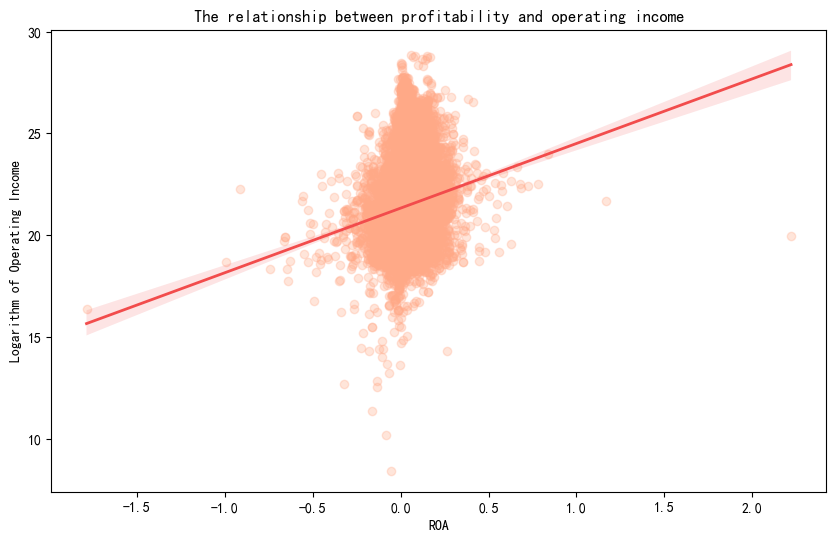

In [37]:
plt.figure(figsize=(10,6))
sns.regplot(x=df_step6['roa'], y=df_step6['log_revt'], 
            scatter_kws={'color':'#FFA987', 'alpha':0.3},
            line_kws={'color':'#F24C4C', 'lw':2})
plt.xlabel('ROA')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between profitability and operating income')
plt.show()

In [39]:
#Examine abnormal values of leverage ratio
df_clean = df_step6[(df_step6['lev'] >= 0) & (df_step6['lev'] <= 1)]

print(df_clean['lev'].describe())

count     25627.0
mean      0.41757
std      0.215176
min      0.013062
25%      0.245135
50%      0.402784
75%      0.567778
max      0.997354
Name: lev, dtype: Float64


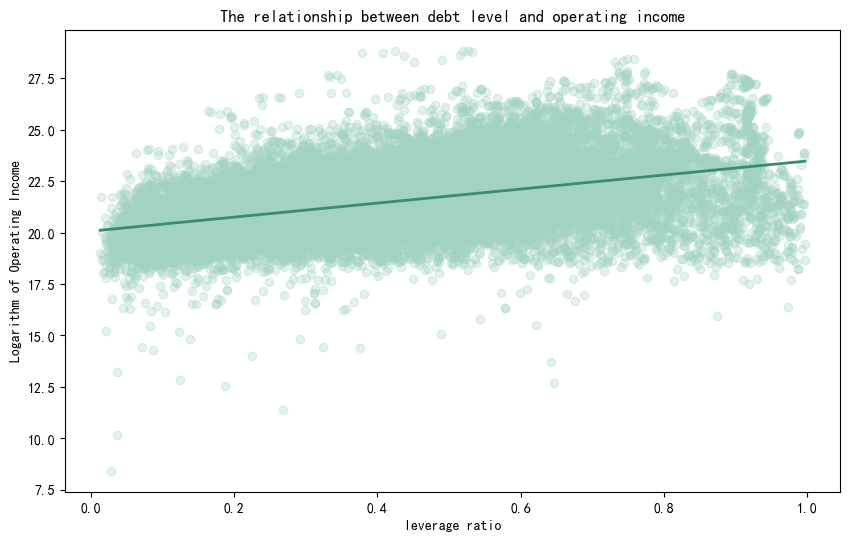

In [40]:
plt.figure(figsize=(10,6))
sns.regplot(
    x=df_clean['lev'], 
    y=df_clean['log_revt'],
    ci=None, 
    scatter_kws={'color':'#A2D3C2', 'alpha':0.3},
    line_kws={'color':'#3B8C6E', 'lw':2}
)
plt.xlabel('leverage ratio')
plt.ylabel('Logarithm of Operating Income')
plt.title('The relationship between debt level and operating income')
plt.show()